<a href="https://colab.research.google.com/github/shifu027/TCC-Pyomo/blob/main/Poymo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Ambiente pronto.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cenários executados.

Tabela Comparativa de Indicadores de Desempenho (KPIs):


,Custo Total (R$),Custo de Energia (R$),Custo de Demanda (R$),Custo de Degradação (R$),Pico de Demanda (kW),Energia Importada (kWh),Energia PV Curtailada (kWh),Tensão Mínima (p.u.),Redução Custo Total (%),Redução Pico Demanda (%)
Cenário,,,,,,,,,,
BAU,414.60,399.77,0.00,14.83,51.20,519.30,0.00,1.00,0.00,0.00
BESS+V1G,165.19,142.74,0.00,22.44,24.50,225.04,537.08,1.00,60.16,52.15
BESS+V2G,133.23,109.07,0.00,24.15,28.95,190.84,537.08,1.00,67.87,43.46


Figuras salvas em /content/figs


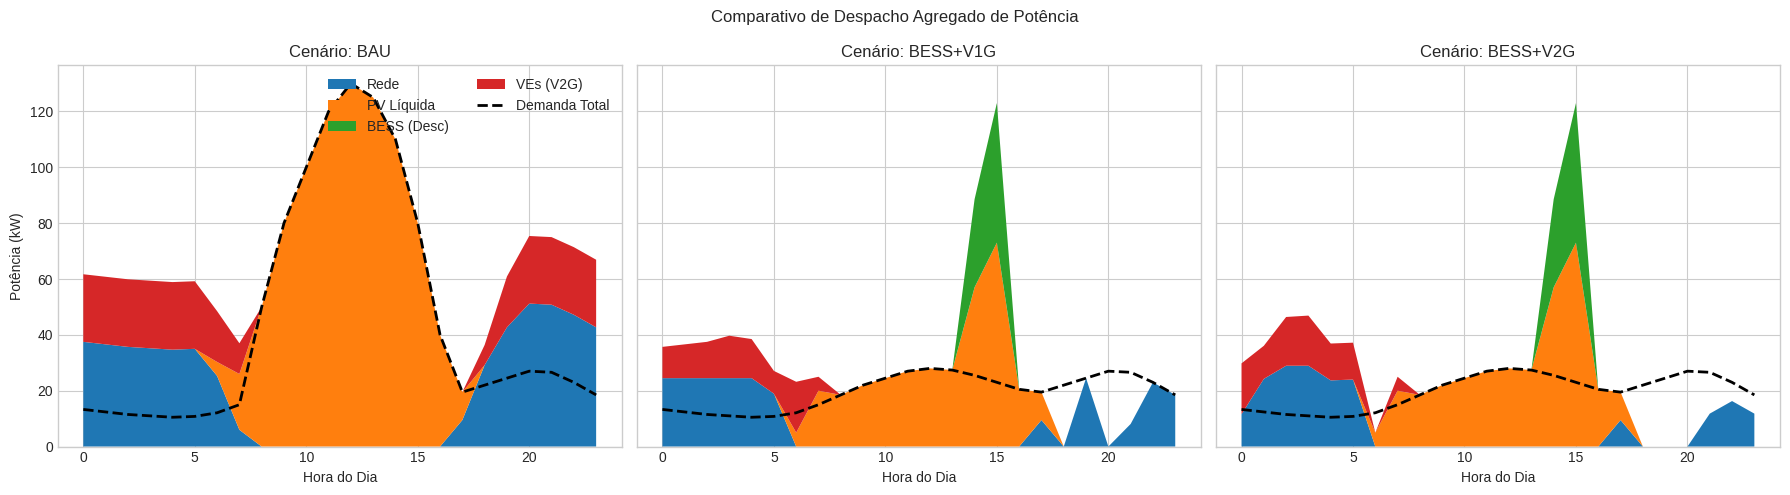

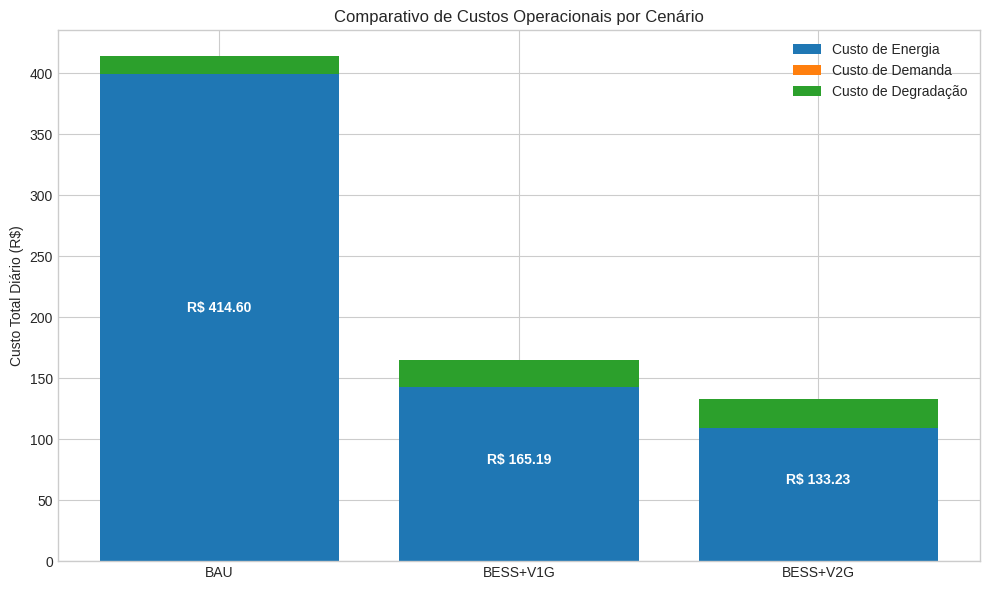

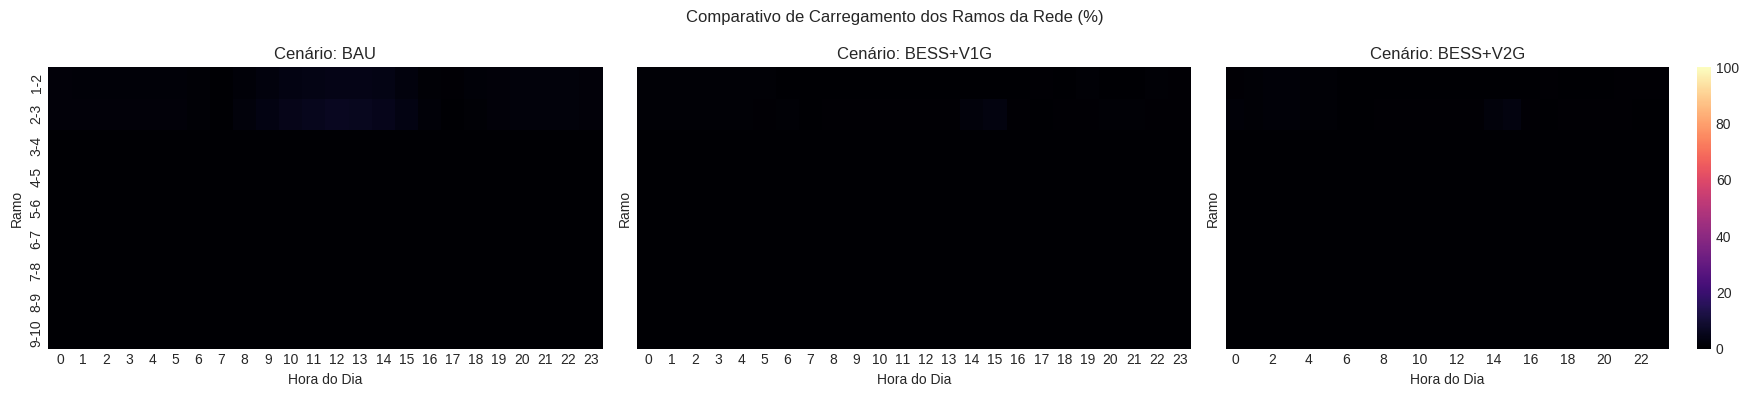

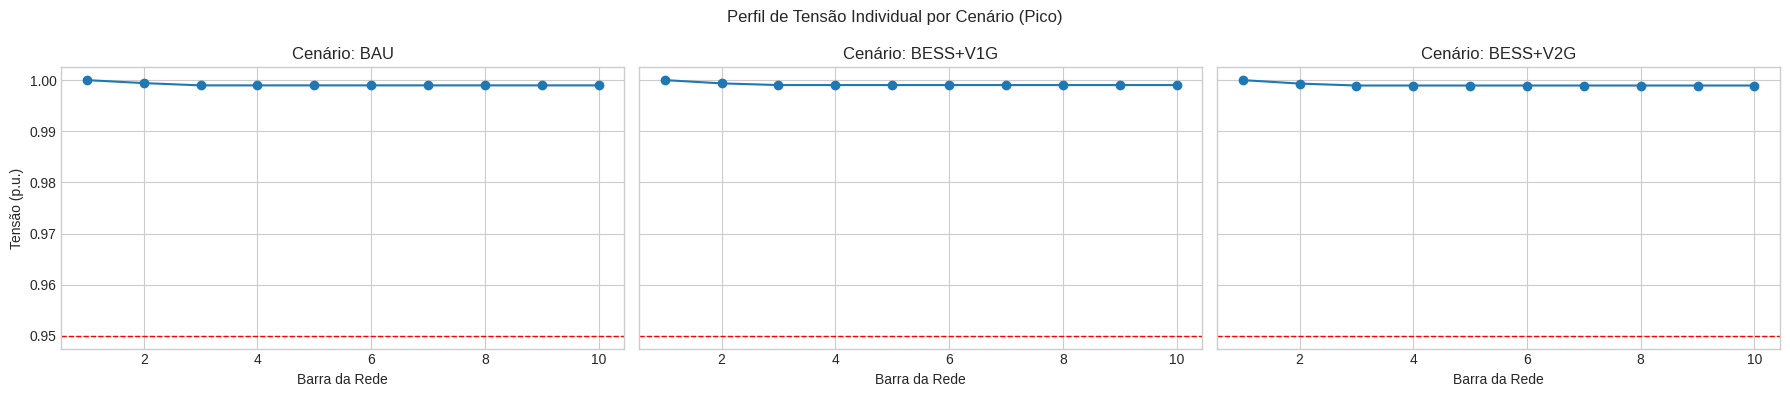

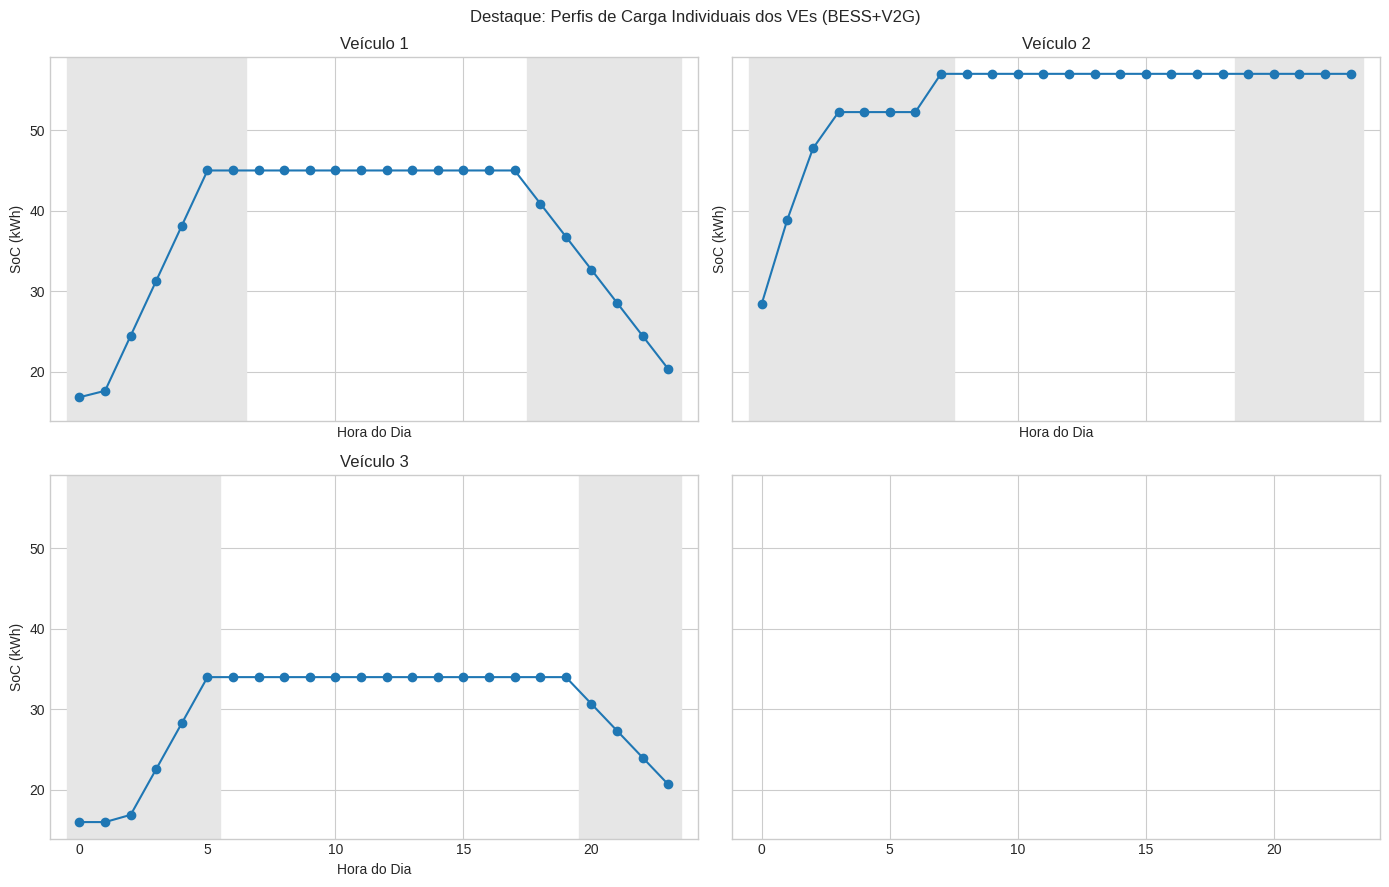

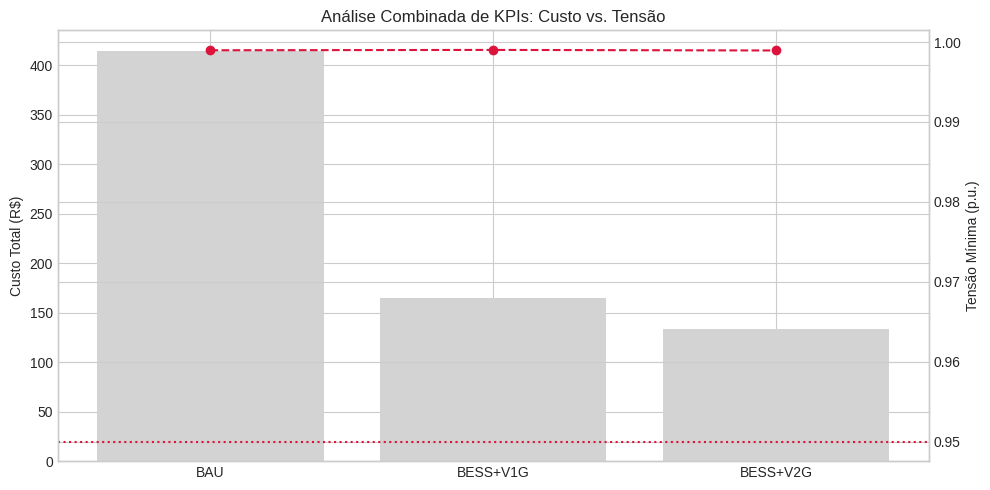

In [25]:
# ============================ SETUP (Colab) ============================
!pip -q install pyomo==6.7.1 pandas==2.2.2 numpy==1.26.4 matplotlib==3.9.0 seaborn==0.13.2
!apt-get -y -qq update >/dev/null
!apt-get -y -qq install coinor-cbc >/dev/null

import os, re, unicodedata, io, math, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyomo.environ as pyo
from collections import deque
from google.colab import drive

print("Ambiente pronto.")

# ============================ MONTAGEM DO DRIVE ============================
drive.mount('/content/drive')
# >>> AJUSTE O CAMINHO ABAIXO PARA SUA PASTA DE DADOS <<<
path_to_data = '/content/drive/MyDrive/TCC_DATA_FILES/'  # <- mude se necessário

# ============================ HELPERS ============================
def norm(s: str) -> str:
    if s is None: return ''
    s = str(s)
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = re.sub(r'[^A-Za-z0-9]+', '_', s.strip().lower())
    s = re.sub(r'_+', '_', s).strip('_')
    return s

def norm_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [norm(c) for c in df.columns]
    return df

def pick(df_or_cols, *aliases, allow_startswith=False, required=True):
    """
    Retorna o primeiro nome existente dentre `aliases`; se allow_startswith=True,
    aceita também colunas que comecem com o alias (ex.: 'hora_h' casa com 'hora').
    """
    cols = df_or_cols.columns if hasattr(df_or_cols, 'columns') else df_or_cols
    cols = list(cols)
    # exato
    for a in aliases:
        if a in cols: return a
    # inicia com
    if allow_startswith:
        for a in aliases:
            for c in cols:
                if c.startswith(a):
                    return c
    if required:
        raise KeyError(f"Coluna não encontrada. Tente {aliases}. Presentes: {cols}")
    return None

def to_float(x, default=None):
    try: return float(x)
    except Exception: return default

def pct_or_pu(x):
    x = to_float(x, None)
    if x is None: return None
    return x/100.0 if x>1.0 else x

# ============================ LEITURA: PARÂMETROS GERAIS (A.1) ============================
gp = pd.read_csv(os.path.join(path_to_data, 'general_parameters.csv'))
gp = norm_cols(gp)

if {'parametro','valor'}.issubset(set(gp.columns)):
    general = {norm(k): to_float(v, v) for k, v in zip(gp['parametro'], gp['valor'])}
else:
    pcol = pick(gp, 'parametro','param','nome','chave', required=False)
    vcol = pick(gp, 'valor','value','val', required=False)
    if pcol and vcol:
        general = {norm(k): to_float(v, v) for k, v in zip(gp[pcol], gp[vcol])}
    else:
        value_cols = [c for c in gp.columns if c not in ('unidade','parametro','param','nome','chave')]
        if not value_cols: raise RuntimeError("general_parameters.csv sem colunas de valor detectáveis.")
        general = {norm(k): to_float(v, v) for k, v in zip(gp.index, gp[value_cols[0]])}

def gget(*names, default=None):
    for n in names:
        k = norm(n)
        if k in general:
            return to_float(general[k], general[k])
    return default

# Bases elétricas e limites
V_LL_BASE_kV  = gget('v_ll_base_kv','v_base_kv','vbase_kv', default=13.8)
S_BASE_kVA    = gget('s_base_kva','s_base_mva', default=1000.0)
S_BASE_kW     = S_BASE_kVA
S_BASE_MVA    = S_BASE_kVA/1000.0
Z_BASE_OHM    = (V_LL_BASE_kV**2)/S_BASE_MVA

DELTA_T_H     = gget('delta_t_h','delta_t', default=1.0)
V_MIN_PU      = gget('v_min_pu', default=0.95)
V_MAX_PU      = gget('v_max_pu', default=1.05)
V_REF_PU      = gget('v_ref_pu', default=1.00)
PF_CARGA      = gget('pf_carga','cosphi','fator_pot', default=0.95)

# BESS
BESS_E_CAP    = gget('bess_e_cap_kwh','capacidade_bess_kwh', default=100.0)
BESS_P_CH_MAX = gget('bess_p_ch_max_kw','pot_max_carga_bess_kw', default=50.0)
BESS_P_DIS_MAX= gget('bess_p_dis_max_kw','pot_max_descarga_bess_kw', default=40.0)
BESS_ETA_CH   = gget('bess_eta_ch','eficiencia_carga_bess', default=0.92)
BESS_ETA_DIS  = gget('bess_eta_dis','eficiencia_descarga_bess', default=0.90)
BESS_SOC_MIN  = gget('bess_soc_min_pu','soc_min_bess_pu', default=0.20)
BESS_SOC_MAX  = gget('bess_soc_max_pu','soc_max_bess_pu', default=0.95)
BESS_SOC_INIT = gget('bess_soc_init_pu','soc_inicial_bess_pu', default=0.50)

# Custos
C_DEG_BESS    = gget('cdeg_bess_r_per_kwh','custo_degradacao_bess_r_kwh', default=0.10)
C_DEG_EV      = gget('cdeg_ev_r_per_kwh','custo_degradacao_ve_r_kwh', default=0.05)
C_CURT        = gget('c_curtailment_r_per_kwh','custo_curtailment_pv_r_kwh', default=0.02)
C_PICO        = gget('c_pico_r_per_kw','custo_demanda_pico_r_kw', default=0.0)

# Nós de conexão (padrões seguros)
BESS_NODE     = int(gget('bess_node', default=2))
PV_NODE       = int(gget('pv_node', default=3))

# Potência reativa: limite de caixa (padrão: 60% de Pmax, ~PF 0,86)
BESS_S_MAX_kW   = max(BESS_P_CH_MAX, BESS_P_DIS_MAX)
BESS_Q_MAX_kVar = gget('bess_q_max_kvar', default=BESS_S_MAX_kW * 0.6)

# ============================ TARIFAS (A.2) ============================
tar = pd.read_csv(os.path.join(path_to_data, 'energy_tariffs.csv'))
tar = norm_cols(tar)
hcol = pick(tar, 'hora','h','hour', allow_startswith=True)      # aceita 'hora_h'
pcol = pick(tar, 'tarifa_r_kwh','tarifa','preco','custo','r_kwh')
tar['hora'] = tar[hcol].astype(int)
tar = tar.sort_values('hora')
T_list = tar['hora'].astype(int).tolist()
C_ENERGIA = {int(r['hora']): float(r[pcol]) for _, r in tar[['hora',pcol]].iterrows()}

# ============================ CARGAS (A.3) ============================
ld = pd.read_csv(os.path.join(path_to_data, 'load_profiles.csv'))
ld = norm_cols(ld)
hcol_ld = pick(ld, 'hora','h','hour', allow_startswith=True)
ld['hora'] = ld[hcol_ld].astype(int)

load_cols = [c for c in ld.columns if c != 'hora']
node_from_col = {}
for c in load_cols:
    m = re.search(r'(\d+)', c)   # extrai número do nó (ex.: 'no_3_kw' -> 3)
    if m: node_from_col[c] = int(m.group(1))

P_carga = {}
for _, row in ld.iterrows():
    t = int(row['hora'])
    for c, j in node_from_col.items():
        P_carga[(j, t)] = P_carga.get((j, t), 0.0) + to_float(row[c], 0.0)

# ============================ PV (A.4) ============================
pv = pd.read_csv(os.path.join(path_to_data, 'pv_profiles.csv'))
pv = norm_cols(pv)
hcol_pv = pick(pv, 'hora','h','hour', allow_startswith=True)
gcol_pv = pick(pv, 'geracao_pv_kw','pv_kw','pv','pv_kwh','geracao')
pv['hora'] = pv[hcol_pv].astype(int)
P_pv = {(PV_NODE, int(r['hora'])): to_float(r[gcol_pv], 0.0) for _, r in pv[['hora', gcol_pv]].iterrows()}

# ============================ EVs (A.5) ============================
ev = pd.read_csv(os.path.join(path_to_data, 'ev_parameters.csv'))
ev = norm_cols(ev)

id_col        = pick(ev, 'id','id_ve','ve_id','idve','veid')
cap_col       = pick(ev, 'cap_kwh','capbateria_kwh','cap_bateria_kwh',
                     'capacidade_kwh','capacidade','capacidade_bateria_kwh')
pch_col       = pick(ev, 'p_ch_kw','p_max_carga_kw','pmax_carga_kw','potencia_max_carga_kw')
pdis_col      = pick(ev, 'p_dis_kw','p_max_descarga_kw','pmax_descarga_kw','potencia_max_descarga_kw')
eta_ch_col    = pick(ev, 'eta_ch','efic_carga','ef_carga','eficiencia_carga')
eta_dis_col   = pick(ev, 'eta_dis','efic_descarga','ef_descarga','eficiencia_descarga')
tin_col       = pick(ev, 't_in','h_chegada','t_chegada','hora_chegada')
tout_col      = pick(ev, 't_out','h_partida','t_partida','hora_partida')
soc_ini_col   = pick(ev, 'soc_ini_pu','soc_inicial_pu','soc_ini_pct','soc_inicial_%',
                     'soc_inicial','soc_ini','soc_inicial')
soc_tgt_col   = pick(ev, 'soc_target_pu','soc_alvo_pu','soc_target_pct','soc_alvo_%',
                     'soc_alvo','soc_target','soc_alvo')
v2g_col       = pick(ev, 'v2g','v2g_01','v2g_0_1','v2g_habilitado_0_1')
ve_node_col   = pick(ev, 'node','no','barra','bus','n','n_','no_', required=False)
qmax_col      = pick(ev, 'q_max_kvar','qmax_kvar','qmax', required=False)  # opcional

def soc_to_kwh(cap_kwh, soc_val):
    pu = pct_or_pu(soc_val)
    return float(cap_kwh) * (pu if pu is not None else 0.0)

V = sorted(ev[id_col].astype(int).tolist())
Emax_VE           = {int(r[id_col]): float(r[cap_col])               for _, r in ev.iterrows()}
Pmax_ch_VE        = {int(r[id_col]): float(r[pch_col])               for _, r in ev.iterrows()}
Pmax_dis_VE       = {int(r[id_col]): float(r[pdis_col])              for _, r in ev.iterrows()}
eta_ch_VE         = {int(r[id_col]): float(r[eta_ch_col])            for _, r in ev.iterrows()}
eta_dis_VE        = {int(r[id_col]): float(r[eta_dis_col])           for _, r in ev.iterrows()}
t_in_VE           = {int(r[id_col]): int(r[tin_col])                 for _, r in ev.iterrows()}
t_out_VE          = {int(r[id_col]): int(r[tout_col])                for _, r in ev.iterrows()}
SoC_init_VE_kwh   = {int(r[id_col]): soc_to_kwh(r[cap_col], r[soc_ini_col]) for _, r in ev.iterrows()}
SoC_target_VE_kwh = {int(r[id_col]): soc_to_kwh(r[cap_col], r[soc_tgt_col]) for _, r in ev.iterrows()}
v2g_flag          = {int(r[id_col]): int(r[v2g_col])                 for _, r in ev.iterrows()}
VE_nodes          = {int(r[id_col]): (int(r[ve_node_col]) if ve_node_col else PV_NODE) for _, r in ev.iterrows()}

# Q máximo de VE: usa coluna se existir; senão 0.6*max(Pch,Pdis)
Smax_VE = {i: max(Pmax_ch_VE[i], Pmax_dis_VE[i]) for i in V}
Qmax_VE = {i: (float(ev.loc[ev[id_col]==i, qmax_col].iloc[0]) if qmax_col and not pd.isna(ev.loc[ev[id_col]==i, qmax_col].iloc[0])
               else Smax_VE[i]*0.6) for i in V}

# Disponibilidade
T = sorted(T_list)
def available(i, t):
    ti, to = t_in_VE[i], t_out_VE[i]
    if ti > to:  # janela cruza meia-noite
        return 1 if (t >= ti or t < to) else 0
    return 1 if (ti <= t < to) else 0
a_disp_VE = {(i, t): available(i, t) for i in V for t in T}

# Mapa de "hora anterior" para equações de balanço de energia (BESS e VEs)
prev_of = {T[idx]: (T[idx-1] if idx>0 else T[-1]) for idx in range(len(T))}

# ============================ REDE (A.6) ============================
net = pd.read_csv(os.path.join(path_to_data, 'network_parameters.csv'))
net = norm_cols(net)
fcol = pick(net, 'from_node','de','from','origem','no_de','no_origem')
tcol = pick(net, 'to_node','para','to','destino','no_para','no_destino')

has_rpu  = 'r_pu' in net.columns
has_xpu  = 'x_pu' in net.columns
has_rohm = 'resistance_ohm' in net.columns
has_xohm = 'reactance_ohm' in net.columns

imax_col = next((c for c in ['i_max_a','imax_a','i_max','corrente_max_a'] if c in net.columns), None)
pmax_col = next((c for c in ['p_max_kw','pmax_kw'] if c in net.columns), None)

E_branches = [(int(r[fcol]), int(r[tcol])) for _, r in net.iterrows()]
N_nodes = sorted(set([i for i,_ in E_branches] + [j for _,j in E_branches] +
                     list({j for (j,_) in P_carga.keys()}) + [PV_NODE, BESS_NODE]))

if has_rpu and has_xpu:
    R_pu = {(int(r[fcol]), int(r[tcol])): float(r['r_pu']) for _, r in net.iterrows()}
    X_pu = {(int(r[fcol]), int(r[tcol])): float(r['x_pu']) for _, r in net.iterrows()}
elif has_rohm and has_xohm:
    R_pu = {(int(r[fcol]), int(r[tcol])): float(r['resistance_ohm'])/Z_BASE_OHM for _, r in net.iterrows()}
    X_pu = {(int(r[fcol]), int(r[tcol])): float(r['reactance_ohm'])/Z_BASE_OHM  for _, r in net.iterrows()}
else:
    XR = 0.8
    R_pu = {(int(r[fcol]), int(r[tcol])): 0.01 for _, r in net.iterrows()}
    X_pu = {(i,j): R_pu[(i,j)]*XR for (i,j) in E_branches}

S_max_ramo_kw = {}
for _, r in net.iterrows():
    i, j = int(r[fcol]), int(r[tcol])
    if pmax_col:
        S_max_ramo_kw[(i,j)] = to_float(r[pmax_col], 9e9)
    elif imax_col:
        Imax = to_float(r[imax_col], 9e6)
        S_max_ramo_kw[(i,j)] = math.sqrt(3.0) * V_LL_BASE_kV * Imax
    else:
        S_max_ramo_kw[(i,j)] = 9e9

children_of = {n: [] for n in N_nodes}
parent_of = {}
for (i,j) in E_branches:
    children_of[i].append(j)
    parent_of[j] = i

SLACK = min([i for i,_ in E_branches])

# ============================ Q de carga (PF -> tan φ) ============================
phi = math.acos(max(min(PF_CARGA, 1.0), -1.0))
tanphi = math.tan(phi)
Q_carga = {(j,t): P_carga.get((j,t),0.0) * tanphi for j in N_nodes for t in T}

# ============================ MODELO (LinDistFlow + Q control) ============================
def run_optimization_scenario(v2g_enabled: bool, bess_present: bool):
    m = pyo.ConcreteModel()
    m.T = pyo.Set(initialize=T)
    m.N = pyo.Set(initialize=N_nodes)
    m.VE= pyo.Set(initialize=V)
    m.E = pyo.Set(initialize=E_branches, dimen=2)

    # Grid e PV curtailment
    m.P_grid      = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_max_pico  = pyo.Var(domain=pyo.NonNegativeReals)
    m.P_curt      = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    # BESS (P e Q)
    m.P_bess_ch   = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.P_bess_dis  = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.Q_bess_inj  = pyo.Var(m.T, domain=pyo.Reals)  # ±Q
    m.SoC_BESS    = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.u_BESS      = pyo.Var(m.T, domain=pyo.Binary)

    # VEs (P e Q)
    m.P_ve_ch     = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.P_ve_dis    = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.Q_ve_inj    = pyo.Var(m.VE, m.T, domain=pyo.Reals)  # ±Q
    m.SoC_VE      = pyo.Var(m.VE, m.T, domain=pyo.NonNegativeReals)
    m.u_VE        = pyo.Var(m.VE, m.T, domain=pyo.Binary)

    # Rede (P, Q, V)
    m.P_ramo      = pyo.Var(m.E, m.T, domain=pyo.Reals)
    m.Q_ramo      = pyo.Var(m.E, m.T, domain=pyo.Reals)
    m.Q_grid      = pyo.Var(m.T, domain=pyo.Reals)
    m.V2          = pyo.Var(m.N, m.T, domain=pyo.NonNegativeReals)

    # Objetivo
    def obj(m):
        c_energia = sum(C_ENERGIA[t]*m.P_grid[t]*DELTA_T_H for t in m.T)
        c_pico    = C_PICO * m.P_max_pico
        c_curt    = sum(C_CURT * m.P_curt[j,t]*DELTA_T_H for j in m.N for t in m.T)
        c_deg_b   = (sum(C_DEG_BESS*(m.P_bess_ch[t]+m.P_bess_dis[t])*DELTA_T_H for t in m.T) if bess_present else 0.0)
        c_deg_ev  = sum(C_DEG_EV*(m.P_ve_ch[i,t]+m.P_ve_dis[i,t])*DELTA_T_H for i in m.VE for t in m.T)
        return c_energia + c_pico + c_curt + c_deg_b + c_deg_ev
    m.OBJ = pyo.Objective(rule=obj, sense=pyo.minimize)

    # Restrições de pico e curt
    m.P_grid_peak = pyo.Constraint(m.T, rule=lambda m,t: m.P_grid[t] <= m.P_max_pico)
    m.curt_limit  = pyo.Constraint(m.N, m.T, rule=lambda m,j,t: m.P_curt[j,t] <= P_pv.get((j,t), 0.0))

    # BESS: energia e potência
    if bess_present:
        SoC_min = BESS_SOC_MIN * BESS_E_CAP
        SoC_max = BESS_SOC_MAX * BESS_E_CAP
        SoC_ini = BESS_SOC_INIT * BESS_E_CAP
        def bess_soc(m, t):
            prev = prev_of[t]
            s_prev = SoC_ini if t==T[0] else m.SoC_BESS[prev]
            return m.SoC_BESS[t] == s_prev + (m.P_bess_ch[t]*BESS_ETA_CH - m.P_bess_dis[t]/BESS_ETA_DIS)*DELTA_T_H
        m.BESS_SoC = pyo.Constraint(m.T, rule=bess_soc)
        m.BESS_box = pyo.Constraint(m.T, rule=lambda m,t: pyo.inequality(SoC_min, m.SoC_BESS[t], SoC_max))
        m.BESS_p_ch= pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_ch[t] <= BESS_P_CH_MAX*m.u_BESS[t])
        m.BESS_p_ds= pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_dis[t] <= BESS_P_DIS_MAX*(1 - m.u_BESS[t]))
        # Q do BESS (limite de caixa)
        m.BESS_Q_limit = pyo.Constraint(m.T, rule=lambda m,t: pyo.inequality(-BESS_Q_MAX_kVar, m.Q_bess_inj[t], BESS_Q_MAX_kVar))
    else:
        m.BESS_zero_P = pyo.Constraint(m.T, rule=lambda m,t: m.P_bess_ch[t] + m.P_bess_dis[t] == 0)
        m.BESS_zero_Q = pyo.Constraint(m.T, rule=lambda m,t: m.Q_bess_inj[t] == 0)

    # VEs: energia e potência (com disponibilidade e V2G)
    def ve_soc(m, i, t):
        prev = prev_of[t]
        s_prev = SoC_init_VE_kwh[i] if t==T[0] else m.SoC_VE[i, prev]
        return m.SoC_VE[i,t] == s_prev + (m.P_ve_ch[i,t]*eta_ch_VE[i] - m.P_ve_dis[i,t]/eta_dis_VE[i])*DELTA_T_H
    m.VE_SoC = pyo.Constraint(m.VE, m.T, rule=ve_soc)

    m.VE_ch_lim = pyo.Constraint(m.VE, m.T,
        rule=lambda m,i,t: m.P_ve_ch[i,t]  <= Pmax_ch_VE[i]*a_disp_VE[(i,t)]*m.u_VE[i,t])
    m.VE_ds_lim = pyo.Constraint(m.VE, m.T,
        rule=lambda m,i,t: m.P_ve_dis[i,t] <= Pmax_dis_VE[i]*a_disp_VE[(i,t)]*(v2g_flag[i] if v2g_enabled else 0)*(1 - m.u_VE[i,t]))

    def ve_target(m, i):
        tpart = t_out_VE[i]
        tidx  = prev_of[tpart]  # hora imediatamente anterior à partida
        return m.SoC_VE[i, tidx] >= SoC_target_VE_kwh[i]
    m.VE_target = pyo.Constraint(m.VE, rule=ve_target)

    # Q dos VEs (limite de caixa + disponibilidade)
    @m.Constraint(m.VE, m.T)
    def VE_Q_limit(m, i, t):
        q_max_avail = Qmax_VE[i] * a_disp_VE[(i,t)]
        return pyo.inequality(-q_max_avail, m.Q_ve_inj[i,t], q_max_avail)

    # Balanço de P (por nó e hora)
    def bal_P(m, j, t):
        if j == SLACK:
            return m.P_grid[t] == sum(m.P_ramo[SLACK,k,t] for (a,k) in m.E if a==SLACK)
        parent = parent_of.get(j, None)
        if parent is None: return pyo.Constraint.Skip
        inflow   = m.P_ramo[parent, j, t]
        outflow  = sum(m.P_ramo[j,k,t] for k in children_of.get(j, []))
        inj_pv   = P_pv.get((j,t),0.0) - m.P_curt[j,t]
        inj_bess = (m.P_bess_dis[t] - m.P_bess_ch[t]) if (j==BESS_NODE and bess_present) else 0.0
        inj_ve   = sum(m.P_ve_dis[i,t] - m.P_ve_ch[i,t] for i in m.VE if VE_nodes[i]==j)
        carga    = P_carga.get((j,t),0.0)
        return inflow - outflow == carga - (inj_pv + inj_bess + inj_ve)
    m.BAL_P = pyo.Constraint(m.N, m.T, rule=bal_P)

    # Balanço de Q
    def bal_Q(m, j, t):
        if j == SLACK:
            return m.Q_grid[t] == sum(m.Q_ramo[SLACK,k,t] for (a,k) in m.E if a==SLACK)
        parent = parent_of.get(j, None)
        if parent is None: return pyo.Constraint.Skip
        inflow  = m.Q_ramo[parent, j, t]
        outflow = sum(m.Q_ramo[j,k,t] for k in children_of.get(j, []))
        q_carga = Q_carga[(j,t)]
        inj_Q_bess = (m.Q_bess_inj[t] if (j == BESS_NODE and bess_present) else 0.0)
        inj_Q_ves  = sum(m.Q_ve_inj[i,t] for i in m.VE if VE_nodes[i] == j)
        inj_Q      = inj_Q_bess + inj_Q_ves
        return inflow - outflow == q_carga - inj_Q
    m.BAL_Q = pyo.Constraint(m.N, m.T, rule=bal_Q)

    # Queda de tensão LinDistFlow: v_j^2 = v_i^2 - 2*(R*P + X*Q)
    @m.Constraint(m.E, m.T)
    def V_drop(m, i, j, t):
        p_pu = m.P_ramo[i,j,t] / S_BASE_kW
        q_pu = m.Q_ramo[i,j,t] / S_BASE_kW
        return m.V2[j,t] == m.V2[i,t] - 2.0*(R_pu[(i,j)]*p_pu + X_pu[(i,j)]*q_pu)

    m.V_slack  = pyo.Constraint(m.T, rule=lambda m,t: m.V2[SLACK,t] == V_REF_PU**2)
    Vmin2, Vmax2 = V_MIN_PU**2, V_MAX_PU**2
    m.V_limits = pyo.Constraint(m.N, m.T, rule=lambda m,j,t: pyo.inequality(Vmin2, m.V2[j,t], Vmax2))

    # Limites P/Q por ramo (caixa)
    m.P_box = pyo.Constraint(m.E, m.T, rule=lambda m,i,j,t:
                             pyo.inequality(-S_max_ramo_kw[(i,j)], m.P_ramo[i,j,t], S_max_ramo_kw[(i,j)]))
    m.Q_box = pyo.Constraint(m.E, m.T, rule=lambda m,i,j,t:
                             pyo.inequality(-S_max_ramo_kw[(i,j)], m.Q_ramo[i,j,t], S_max_ramo_kw[(i,j)]))

    solver_name = 'cbc' if shutil.which('cbc') else 'glpk'
    res = pyo.SolverFactory(solver_name).solve(m, tee=False)
    return res, m

# ============================ BAU (simulação determinística) ============================
def simulate_bau():
    df = pd.DataFrame(index=T); df.index.name='hora'
    # VE carrega no máximo quando disponível (sem V2G); BESS ausente
    P_ve_ch_nodal = {(j,t):0.0 for j in N_nodes for t in T}
    for i in V:
        node = VE_nodes[i]
        for t in T:
            if a_disp_VE[(i,t)]==1:
                P_ve_ch_nodal[(node,t)] += Pmax_ch_VE[i]

    p_inj = {(j,t): P_pv.get((j,t),0.0) - P_carga.get((j,t),0.0) - P_ve_ch_nodal.get((j,t),0.0)
             for j in N_nodes for t in T}
    q_need= {(j,t): Q_carga[(j,t)] for j in N_nodes for t in T}

    P_ramo = {}; Q_ramo = {}
    for t in T:
        P_need = {j: -p_inj[(j,t)] for j in N_nodes}
        Q_need = {j:  q_need[(j,t)] for j in N_nodes}
        for j in sorted(N_nodes, reverse=True):
            if j==SLACK: continue
            i = parent_of.get(j, None)
            if i is None: continue
            P_ramo[(i,j,t)] = P_need[j] + sum(P_ramo.get((j,k,t),0.0) for k in children_of[j])
            Q_ramo[(i,j,t)] = Q_need[j] + sum(Q_ramo.get((j,k,t),0.0) for k in children_of[j])

    V2 = {(SLACK,t): V_REF_PU**2 for t in T}
    for t in T:
        q = deque(children_of[SLACK])
        while q:
            j = q.popleft()
            i = parent_of[j]
            p_pu = (P_ramo.get((i,j,t),0.0))/S_BASE_kW
            q_pu = (Q_ramo.get((i,j,t),0.0))/S_BASE_kW
            V2[(j,t)] = V2[(i,t)] - 2.0*(R_pu[(i,j)]*p_pu + X_pu[(i,j)]*q_pu)
            for k in children_of[j]: q.append(k)

    df['P_grid_kW']        = [sum(P_ramo.get((SLACK,k,t),0.0) for k in children_of[SLACK]) for t in T]
    df['P_grid_kW']        = df['P_grid_kW'].clip(lower=0.0)
    df['P_carga_total_kW'] = [sum(P_carga.get((j,t),0.0) for j in N_nodes) for t in T]
    df['P_pv_total_kW']    = [sum(P_pv.get((j,t),0.0) for j in N_nodes) for t in T]
    df['P_ve_ch_total_kW'] = [sum(P_ve_ch_nodal.get((j,t),0.0) for j in N_nodes) for t in T]
    df['P_ve_dis_total_kW']= 0.0
    df['P_curt_total_kW']  = 0.0
    for j in N_nodes:
        df[f'V_no_{j}_pu'] = [math.sqrt(max(V2.get((j,t), (V_REF_PU**2)), 0.0)) for t in T]

    pico = df['P_grid_kW'].max()
    c_energia = sum(C_ENERGIA[t]*df.loc[t,'P_grid_kW']*DELTA_T_H for t in T)
    c_pico    = C_PICO*pico
    c_deg     = sum(C_DEG_EV*df.loc[t,'P_ve_ch_total_kW']*DELTA_T_H for t in T)
    kpis = {'Custo de Energia': c_energia, 'Custo de Demanda': c_pico, 'Custo de Degradação': c_deg}

    det = {}
    ramoP_df = pd.DataFrame(index=T, columns=[f'{i}-{j}' for (i,j) in E_branches])
    ramoQ_df = pd.DataFrame(index=T, columns=[f'{i}-{j}' for (i,j) in E_branches])
    for t in T:
        for (i,j) in E_branches:
            ramoP_df.loc[t, f'{i}-{j}'] = P_ramo.get((i,j,t),0.0)
            ramoQ_df.loc[t, f'{i}-{j}'] = Q_ramo.get((i,j,t),0.0)
    det['ramoP_df'] = ramoP_df
    det['ramoQ_df'] = ramoQ_df
    return df, kpis, det

# ============================ EXECUÇÃO ============================
results_repo = {}
# BAU
results_repo['BAU'] = {}
results_repo['BAU']['agregado'], results_repo['BAU']['kpis'], results_repo['BAU']['detalhado'] = simulate_bau()

# Otimizados
scenarios_opt = {'BESS+V1G': {'v2g': False, 'bess': True},
                 'BESS+V2G': {'v2g': True,  'bess': True}}

for name, cfg in scenarios_opt.items():
    res, m = run_optimization_scenario(v2g_enabled=cfg['v2g'], bess_present=cfg['bess'])
    agg = pd.DataFrame(index=T); agg.index.name='hora'
    agg['P_grid_kW']         = [pyo.value(m.P_grid[t]) for t in T]
    agg['P_carga_total_kW']  = [sum(P_carga.get((j,t),0.0) for j in N_nodes) for t in T]
    agg['P_pv_total_kW']     = [sum(P_pv.get((j,t),0.0) for j in N_nodes) for t in T]
    agg['P_curt_total_kW']   = [sum(pyo.value(m.P_curt[j,t]) for j in N_nodes) for t in T]
    agg['P_bess_ch_kW']      = [pyo.value(m.P_bess_ch[t]) if cfg['bess'] else 0.0 for t in T]
    agg['P_bess_dis_kW']     = [pyo.value(m.P_bess_dis[t]) if cfg['bess'] else 0.0 for t in T]
    agg['Q_bess_kVAr']       = [pyo.value(m.Q_bess_inj[t]) if cfg['bess'] else 0.0 for t in T]
    agg['P_ve_ch_total_kW']  = [sum(pyo.value(m.P_ve_ch[i,t]) for i in V) for t in T]
    agg['P_ve_dis_total_kW'] = [sum(pyo.value(m.P_ve_dis[i,t]) for i in V) for t in T]
    agg['Q_ve_total_kVAr']   = [sum(pyo.value(m.Q_ve_inj[i,t]) for i in V) for t in T]
    for j in N_nodes:
        agg[f'V_no_{j}_pu'] = [math.sqrt(max(pyo.value(m.V2[j,t]), 0.0)) for t in T]

    custos = {
        'Custo de Energia': sum(C_ENERGIA[t]*pyo.value(m.P_grid[t])*DELTA_T_H for t in T),
        'Custo de Demanda': C_PICO * pyo.value(m.P_max_pico),
        'Custo de Degradação': pyo.value(
            (sum(C_DEG_BESS*(m.P_bess_ch[t]+m.P_bess_dis[t])*DELTA_T_H for t in T) if cfg['bess'] else 0.0)
            + sum(C_DEG_EV*(m.P_ve_ch[i,t]+m.P_ve_dis[i,t])*DELTA_T_H for i in V for t in T)
        )
    }
    det = {}
    ramoP_df = pd.DataFrame(index=T, columns=[f'{i}-{j}' for (i,j) in E_branches])
    ramoQ_df = pd.DataFrame(index=T, columns=[f'{i}-{j}' for (i,j) in E_branches])
    for t in T:
        for (i,j) in E_branches:
            ramoP_df.loc[t, f'{i}-{j}'] = pyo.value(m.P_ramo[i,j,t])
            ramoQ_df.loc[t, f'{i}-{j}'] = pyo.value(m.Q_ramo[i,j,t])
    det['ramoP_df'] = ramoP_df
    det['ramoQ_df'] = ramoQ_df

    results_repo[name] = {'agregado': agg, 'kpis': custos, 'detalhado': det}

print("Cenários executados.")

# ============================ KPIs E RESUMO ============================
summary_rows = []
for scenario in ['BAU','BESS+V1G','BESS+V2G']:
    if scenario not in results_repo: continue
    agg  = results_repo[scenario]['agregado']
    kpis = results_repo[scenario]['kpis']
    vcols = [c for c in agg.columns if c.startswith('V_no_')]
    summary_rows.append({
        'Cenário': scenario,
        'Custo Total (R$)': kpis.get('Custo de Energia',0)+kpis.get('Custo de Demanda',0)+kpis.get('Custo de Degradação',0),
        'Custo de Energia (R$)': kpis.get('Custo de Energia',0),
        'Custo de Demanda (R$)': kpis.get('Custo de Demanda',0),
        'Custo de Degradação (R$)': kpis.get('Custo de Degradação',0),
        'Pico de Demanda (kW)': agg['P_grid_kW'].max(),
        'Energia Importada (kWh)': agg['P_grid_kW'].sum()*DELTA_T_H,
        'Energia PV Curtailada (kWh)': agg['P_curt_total_kW'].sum()*DELTA_T_H,
        'Tensão Mínima (p.u.)': agg[vcols].min().min() if vcols else np.nan
    })
summary_df = pd.DataFrame(summary_rows).set_index('Cenário')
if 'BAU' in summary_df.index:
    bau = summary_df.loc['BAU']
    summary_df['Redução Custo Total (%)'] = (1 - summary_df['Custo Total (R$)']/bau['Custo Total (R$)'])*100
    summary_df['Redução Pico Demanda (%)'] = (1 - summary_df['Pico de Demanda (kW)']/bau['Pico de Demanda (kW)'])*100

pd.options.display.float_format = '{:,.2f}'.format
print("\nTabela Comparativa de Indicadores de Desempenho (KPIs):")
display(summary_df)

# ============================ GRÁFICOS (salvos com os nomes do TCC) ============================
os.makedirs('/content/figs', exist_ok=True)

# 1) Despacho agregado por cenário (Rede, PV líquida, BESS, VEs)
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)
for ax, sc in zip(axes, ['BAU','BESS+V1G','BESS+V2G']):
    agg = results_repo[sc]['agregado']
    t = agg.index
    rede = agg['P_grid_kW'].values
    pv_liq = (agg['P_pv_total_kW'] - agg['P_curt_total_kW']).values
    bess_desc = (agg['P_bess_dis_kW'] - agg['P_bess_ch_kW']).values if sc!='BAU' else np.zeros_like(rede)
    ve_v2g = (agg['P_ve_dis_total_kW'] - agg['P_ve_ch_total_kW']).values
    ax.stackplot(t, rede, pv_liq.clip(min=0), (-bess_desc).clip(min=0), (-ve_v2g).clip(min=0),
                 labels=['Rede','PV Líquida','BESS (Desc)','VEs (V2G)'])
    ax.plot(t, (rede + pv_liq + bess_desc + ve_v2g), 'k--', linewidth=2, label='Demanda Total')
    ax.set_title(f"Cenário: {sc}")
    ax.set_xlabel('Hora do Dia')
axes[0].set_ylabel('Potência (kW)')
axes[0].legend(loc='upper right', ncol=2)
plt.suptitle('Comparativo de Despacho Agregado de Potência')
plt.tight_layout()
plt.savefig('/content/figs/despacho_cenarios.png', dpi=200)

# 2) Custos empilhados
fig, ax = plt.subplots(figsize=(10,6))
labels = ['BAU','BESS+V1G','BESS+V2G']
energia = [results_repo[s]['kpis']['Custo de Energia'] for s in labels]
demanda = [results_repo[s]['kpis']['Custo de Demanda'] for s in labels]
degr    = [results_repo[s]['kpis']['Custo de Degradação'] for s in labels]
ax.bar(labels, energia, label='Custo de Energia')
ax.bar(labels, demanda, bottom=energia, label='Custo de Demanda')
ax.bar(labels, degr, bottom=np.array(energia)+np.array(demanda), label='Custo de Degradação')
for i, s in enumerate(labels):
    total = energia[i]+demanda[i]+degr[i]
    ax.text(i, total*0.5, f"R$ {total:,.2f}", ha='center', va='center', fontsize=10, color='white', weight='bold')
ax.set_title('Comparativo de Custos Operacionais por Cenário')
ax.set_ylabel('Custo Total Diário (R$)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/figs/custos_cenarios.png', dpi=200)

# 3) Heatmaps de carregamento por ramo (em % do limite)
def plot_heatmaps():
    fig, axes = plt.subplots(1,3, figsize=(18,4), sharey=True)
    for ax, sc in zip(axes, ['BAU','BESS+V1G','BESS+V2G']):
        det = results_repo[sc]['detalhado']
        ramoP_df = det['ramoP_df'].astype(float)
        load_pct = ramoP_df.copy()
        for col in ramoP_df.columns:
            i,j = map(int, col.split('-'))
            load_pct[col] = 100.0*np.abs(ramoP_df[col])/S_max_ramo_kw[(i,j)]
        sns.heatmap(load_pct.T, ax=ax, cmap='magma', cbar=(ax is axes[-1]),
                    vmin=0, vmax=100)
        ax.set_title(f"Cenário: {sc}")
        ax.set_xlabel('Hora do Dia')
        ax.set_ylabel('Ramo')
    plt.suptitle('Comparativo de Carregamento dos Ramos da Rede (%)')
    plt.tight_layout()
    plt.savefig('/content/figs/carregamento_cenarios.png', dpi=200)
plot_heatmaps()

# 4) Perfis de tensão no pico (19h por padrão, ou o horário de maior P_grid)
def hora_pico(agg):
    try:
        return int(agg['P_grid_kW'].idxmax())
    except:
        return 19
fig, axes = plt.subplots(1,3, figsize=(18,4), sharey=True)
for ax, sc in zip(axes, ['BAU','BESS+V1G','BESS+V2G']):
    agg = results_repo[sc]['agregado']
    tpk = hora_pico(agg)
    barras = [int(c.split('_')[2]) for c in agg.columns if c.startswith('V_no_')]
    tens = [float(agg.loc[tpk, f'V_no_{b}_pu']) for b in barras]
    ax.plot(barras, tens, marker='o')
    ax.axhline(0.95, ls='--', c='r', lw=1)
    ax.set_title(f"Cenário: {sc}")
    ax.set_xlabel('Barra da Rede')
axes[0].set_ylabel('Tensão (p.u.)')
plt.suptitle(f'Perfil de Tensão Individual por Cenário (Pico)')
plt.tight_layout()
plt.savefig('/content/figs/tensao_pico.png', dpi=200)

# 5) SoC individual dos VEs (cenário BESS+V2G) – se existir
if 'BESS+V2G' in results_repo:
    # Reconstituir SoC dos VEs a partir do modelo re-otimizado (executa de novo localmente)
    res, m = run_optimization_scenario(v2g_enabled=True, bess_present=True)
    fig, axs = plt.subplots(2, 2, figsize=(14,9), sharex=True, sharey=True)
    axs = axs.flatten()
    for idx, i in enumerate(V[:4]):  # mostra até 4 VEs
        soc = [pyo.value(m.SoC_VE[i,t]) for t in T]
        axs[idx].plot(T, soc, marker='o')
        axs[idx].set_title(f'Veículo {i}')
        axs[idx].set_xlabel('Hora do Dia'); axs[idx].set_ylabel('SoC (kWh)')
        # sombreia janelas de disponibilidade
        for t in T:
            if a_disp_VE[(i,t)]==1:
                axs[idx].axvspan(t-0.5, t+0.5, color='0.9')
    plt.suptitle('Destaque: Perfis de Carga Individuais dos VEs (BESS+V2G)')
    plt.tight_layout()
    plt.savefig('/content/figs/soc_ve_BESS_V2G.png', dpi=200)

# 6) KPI “global” (custo x tensão mínima)
fig, ax1 = plt.subplots(figsize=(10,5))
cen = summary_df.index.tolist()
custos = summary_df['Custo Total (R$)'].tolist()
ax1.bar(cen, custos, color='lightgray', label='Custo Total (R$)')
ax1.set_ylabel('Custo Total (R$)')
ax2 = ax1.twinx()
ax2.plot(cen, summary_df['Tensão Mínima (p.u.)'], 'o--', color='crimson', label='Tensão Mínima')
ax2.axhline(0.95, ls=':', color='crimson')
ax2.set_ylabel('Tensão Mínima (p.u.)')
plt.title('Análise Combinada de KPIs: Custo vs. Tensão')
plt.tight_layout()
plt.savefig('/content/figs/kpi_global.png', dpi=200)

print("Figuras salvas em /content/figs")
